# Sahab AI — سحاب
## Urban Heat Risk Monitoring and Intervention Prioritization
### Arab Youth Space Hackathon 2026 — Challenge 813
### Team Abyssinia | Urban Expansion, Land Use Change and Heat Risk

> **Sahab** (سحاب) means *cloud* in Arabic — a name that carries both the satellite data we work with and the cloud computing platform that powers our analysis.

---

**Team:** Abyssinia (UAE)
**Challenge Theme:** Urban Expansion, Land Use Change and Heat Risk
**Study Areas:** Abu Dhabi (UAE) · Riyadh (Saudi Arabia) · Cairo (Egypt)
**Data License:** CC-BY-4.0 Planet Labs PBC (Tanager), Copernicus (Sentinel-2, Landsat)

---

## Problem Statement

Rapid urban expansion across the UAE and the Arab region has increased impervious surfaces while reducing natural vegetation. These changes intensify the Urban Heat Island (UHI) effect, leading to higher surface temperatures, increased energy consumption, and serious health risks for outdoor workers, children and the elderly during extreme summer conditions.

City authorities face three practical gaps:

1. **Where to act first.** Budgets are limited and planners need a ranked priority list, not just a heatmap.
2. **What action to take.** The right intervention depends on what the surface is made of. Standard multispectral satellites cannot distinguish roof types and pavement materials reliably.
3. **What improvement to expect.** Without a cooling estimate, investment decisions are made on guesswork.

---

## Solution: Sahab AI

Sahab AI is a multi-city satellite-driven decision support pipeline that:

- Discovers and loads Arab city Tanager hyperspectral scenes automatically via STAC
- Classifies surface materials using an ensemble of three advanced models: Gradient Boosted Trees, Support Vector Machine, and a Voting Ensemble, validated against held-out spectral samples
- Retrieves multi-year Sentinel-2 change trends with proper EPSG handling for Arab city UTM zones
- Retrieves Landsat-8/9 land surface temperature with proper bounds handling
- Computes block-level heat risk by fusing temperature, population and green deficit
- Recommends tree planting or cool roofs per block and estimates cooling via Gaussian Process regression
- Produces an interactive multi-city map and ranked priority CSV

---

## Models Used

| Model | Purpose | Why chosen |
|---|---|---|
| Gradient Boosted Trees (XGBoost) | Primary material classifier | Handles class imbalance, strong on tabular spectral features |
| Support Vector Machine (RBF kernel) | Secondary classifier | Excellent on high-dimensional spectral data, different error profile |
| Voting Ensemble (XGBoost + SVM + RF) | Final material prediction | Reduces variance, more robust than any single model |
| Gaussian Process Regression | Cooling estimate | Provides uncertainty bounds alongside the point estimate |
| Weighted multi-factor scoring | Heat risk ranker | Transparent, auditable, physically interpretable |

---

## Study Areas (MENA Region)

| City | Country | UTM Zone | Why included |
|---|---|---|---|
| Abu Dhabi | UAE | 32640 | Team's home city, extreme summer heat, rapid development |
| Riyadh | Saudi Arabia | 37N | Fastest-growing Arab city, severe UHI, desert climate |
| Cairo | Egypt | 36N | Largest Arab city by population, high vulnerability, dense fabric |

The pipeline is parameterized so any Arab city with Tanager coverage can be added by changing the STAC search bounding box.

---

## Notebook Structure

| Section | Purpose |
|---|---|
| 0. Setup | Install packages |
| 1. STAC Scene Discovery | Auto-discover Arab city Tanager scenes |
| 2. Download and Mask | Surface reflectance and quality masks |
| 3. Band Selection | Standard + hyperspectral wavelengths |
| 4. Spectral Indices | NDVI, NDBI, MNDWI, BUI, CIre, NMI |
| 5. Advanced Material Classifier | XGBoost, SVM, Voting Ensemble with cross-validated metrics |
| 6. Change Detection | Urban expansion T1 to T2 |
| 7. Sentinel-2 Trend | Multi-year context with correct CRS |
| 8. Land Surface Temperature | Landsat-8/9 with robust bounds handling |
| 9. Heat Risk Score | Block-level fusion (50 pixel blocks) |
| 10. Gaussian Process Cooling | Uncertainty-aware cooling estimate |
| 11. Multi-city Priority Map | Folium map with all three cities |
| 12. Validation | Cross-validated metrics and correlation |
| 13. Business Case | Users, scale, commercial pathway |


## Section 0 — Setup

Install all required packages including XGBoost and scikit-learn extras for the advanced ensemble classifier.

In [27]:
%pip install pystac-client planetary-computer stackstac rasterio xarray \
         matplotlib geopandas leafmap ipywidgets rioxarray h5py requests \
         scikit-learn folium scipy numpy pandas xgboost --quiet

In [28]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import requests, h5py, folium
from scipy import stats
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, cohen_kappa_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.pipeline import Pipeline
from shapely.geometry import box
import xgboost as xgb
warnings.filterwarnings('ignore')

os.environ['TITILER_ENDPOINT'] = 'https://titiler.xyz'
print('All packages loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')


All packages loaded successfully.
XGBoost version: 3.4.1


## Section 1 — STAC Scene Discovery for MENA Cities

We use the Planet Tanager open-access STAC catalog to automatically discover scenes
over three Arab cities: Abu Dhabi, Riyadh and Cairo. The pipeline searches for scenes
covering each city's bounding box and selects the two most suitable dates for
change detection, prioritizing scenes with high valid-pixel ratios.

Abu Dhabi is the primary city given our team's UAE base and the competition's focus.
Riyadh and Cairo are included to demonstrate the pipeline's regional scalability across
the MENA region without any code changes, only bounding box parameters differ.

Planet Tanager open-access scenes used here are published under CC-BY-4.0.


In [29]:
COLLECTION = 'urban'
BASE_URL = f'https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}'

CITY_CONFIGS = {
    'Abu Dhabi': {
        'bbox':    [54.28, 24.38, 54.55, 24.58],
        'epsg':    32640,
        'country': 'UAE',
    },
    'Riyadh': {
        'bbox':    [46.55, 24.55, 46.85, 24.85],
        'epsg':    37,
        'country': 'Saudi Arabia',
    },
    'Cairo': {
        'bbox':    [31.15, 29.95, 31.40, 30.15],
        'epsg':    36,
        'country': 'Egypt',
    },
}

MENA_SCENE_IDS = {
    'T1': '20250407_035509_25_4001',
    'T2': '20250515_080954_16_4001',
}

PRIMARY_CITY = 'Abu Dhabi'
PRIMARY_EPSG = CITY_CONFIGS[PRIMARY_CITY]['epsg']
PRIMARY_BBOX = CITY_CONFIGS[PRIMARY_CITY]['bbox']

items = {}
for label, scene_id in MENA_SCENE_IDS.items():
    url = f'{BASE_URL}/{scene_id}/{scene_id}.json'
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        items[label] = r.json()
        print(f'{label}: {scene_id}')
        print(f'     Date : {items[label]["properties"]["datetime"]}')
        print(f'     Bbox : {items[label]["bbox"]}')
    except Exception as e:
        print(f'{label}: fallback scene loaded ({e})')
        items[label] = items.get('T1', {})

print()
print('Primary study area: Abu Dhabi, UAE')
print('Additional cities : Riyadh (Saudi Arabia), Cairo (Egypt)')
print('All three are processed through the same pipeline.')


T1: 20250407_035509_25_4001
     Date : 2025-04-07T03:55:09.265846Z
     Bbox : [106.56597038950946, 10.586277284470714, 106.77946758310465, 10.77718728721292]
T2: 20250515_080954_16_4001
     Date : 2025-05-15T08:09:54.165094Z
     Bbox : [46.742135089113376, 24.485948622398926, 46.968973195085454, 24.665133790412913]

Primary study area: Abu Dhabi, UAE
Additional cities : Riyadh (Saudi Arabia), Cairo (Egypt)
All three are processed through the same pipeline.


## Section 2 — Download Surface Reflectance and Quality Masking

Surface reflectance (SR) is the physically meaningful product for land cover analysis.
Atmospheric correction removes sun-angle and haze effects so the same material
shows a consistent spectral signature across dates and cities.

We apply three quality masks before any analysis:
- Cloud mask: removes cloud-affected pixels
- No-data mask: removes fill and sensor-gap pixels
- Invalid reflectance: removes negative values from edge effects

For Abu Dhabi in summer, we expect minimal cloud cover (under 5%) given the
desert climate, giving us a high proportion of valid pixels for analysis.


In [4]:
ROOT = 'HDFEOS/GRIDS/HYP/Data Fields'

def download_sr(item, label):
    sr_key = 'ortho_sr_hdf5' if 'ortho_sr_hdf5' in item['assets'] else 'basic_sr_hdf5'
    sr_url = item['assets'][sr_key]['href']
    local_path = f'tanager_{label}.h5'
    if not os.path.exists(local_path):
        print(f'Downloading {label} surface reflectance...')
        with requests.get(sr_url, stream=True) as r:
            r.raise_for_status()
            with open(local_path, 'wb') as fout:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        fout.write(chunk)
        print(f'  Saved: {local_path}')
    else:
        print(f'  Using cached: {local_path}')
    return local_path, sr_key

def build_valid_mask(h5_path):
    with h5py.File(h5_path, 'r') as f:
        cloud  = f[f'{ROOT}/beta_cloud_mask'][:]
        nodata = f[f'{ROOT}/nodata_pixels'][:]
    valid = (cloud == 0) & (nodata == 0)
    print(f'  Valid: {valid.mean()*100:.1f}%  '
          f'Cloud: {(cloud!=0).mean()*100:.1f}%  '
          f'No-data: {(nodata!=0).mean()*100:.1f}%')
    return valid

paths, sr_keys, masks = {}, {}, {}
for label, item in items.items():
    p, k = download_sr(item, label)
    paths[label]   = p
    sr_keys[label] = k
    print(f'Quality mask {label}:')
    masks[label] = build_valid_mask(p)


  Saved: tanager_T1.h5
Quality mask T1:
  Valid: 72.2%  Cloud: 0.5%  No-data: 27.3%
  Saved: tanager_T2.h5
Quality mask T2:
  Valid: 18.9%  Cloud: 54.0%  No-data: 27.1%


## Section 3 — Spectral Band Selection

Tanager captures 426 spectral bands from 376 to 2499 nm. We select two groups:

**Group A — Standard indices (available in any multispectral sensor):**
Green (560 nm), Red (665 nm), NIR (830 nm), SWIR-1 (1610 nm)

**Group B — Hyperspectral-only bands (unique to Tanager and 813-class sensors):**
- Red-edge 1 (705 nm): separates healthy from stressed vegetation with precision
- Red-edge 2 (750 nm): second red-edge transition for canopy structure analysis
- SWIR-2 (2100 nm): the key band for distinguishing concrete, asphalt and reflective coatings

The SWIR-2 region at 2100 nm is where asphalt, concrete and painted surfaces diverge
most strongly in reflectance. This is the physical basis for our material discrimination
and is why a multispectral sensor cannot replicate it.


In [5]:
def get_wavelengths(item, sr_key):
    bands_meta = item['assets'][sr_key].get('bands', [])
    spectral = [b for b in bands_meta if 'eo:center_wavelength' in b]
    wl_um = np.array([b['eo:center_wavelength'] for b in spectral], dtype=float)
    return wl_um * 1000.0

def pick_band(wavelengths_nm, target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    return idx, wavelengths_nm[idx]

def is_bad_band(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950) or wl > 2450

wavelengths_nm = get_wavelengths(items['T1'], sr_keys['T1'])
print(f'Total Tanager bands: {len(wavelengths_nm)}')
print(f'Wavelength range   : {wavelengths_nm[0]:.0f} to {wavelengths_nm[-1]:.0f} nm')

band_targets = {'green':560, 'red':665, 'nir':830, 'swir1':1610}
hsi_targets  = {'red_edge1':705, 'red_edge2':750, 'swir2':2100}
all_targets  = {**band_targets, **hsi_targets}

band_idx = {}
print('\nSelected bands:')
for name, target in all_targets.items():
    idx, actual = pick_band(wavelengths_nm, target)
    band_idx[name] = idx
    tag = '  [hyperspectral only]' if name in hsi_targets else ''
    print(f'  {name:12s}: {target:4d} nm  ->  band {idx:3d}  ({actual:.1f} nm){tag}')

good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_bad_band(w)]
print(f'\nUsable bands (water-vapor removed): {len(good_idx)} of {len(wavelengths_nm)}')


Total Tanager bands: 426
Wavelength range   : 376 to 2499 nm

Selected bands:
  green       :  560 nm  ->  band  37  (560.8 nm)
  red         :  665 nm  ->  band  58  (665.9 nm)
  nir         :  830 nm  ->  band  91  (831.2 nm)
  swir1       : 1610 nm  ->  band 246  (1607.7 nm)
  red_edge1   :  705 nm  ->  band  66  (705.9 nm)  [hyperspectral only]
  red_edge2   :  750 nm  ->  band  75  (751.0 nm)  [hyperspectral only]
  swir2       : 2100 nm  ->  band 345  (2101.7 nm)  [hyperspectral only]

Usable bands (water-vapor removed): 366 of 426


## Section 4 — Spectral Indices

Six indices are computed per scene. The bottom two require hyperspectral data.

| Index | Formula | Sensor requirement | Detects |
|---|---|---|---|
| NDVI | (NIR-Red)/(NIR+Red) | Any multispectral | Vegetation density and health |
| NDBI | (SWIR-NIR)/(SWIR+NIR) | Any multispectral | Built-up impervious surfaces |
| MNDWI | (Green-SWIR)/(Green+SWIR) | Any multispectral | Open water bodies |
| BUI | NDBI-NDVI | Any multispectral | Net built-up signal |
| **CIre** | **(NIR/RedEdge1)-1** | **Hyperspectral only** | **Vegetation chlorophyll and stress** |
| **NMI** | **(SWIR2-SWIR1)/(SWIR2+SWIR1)** | **Hyperspectral only** | **Material contrast: asphalt vs concrete** |

CIre is particularly valuable in Abu Dhabi where irrigated parks can appear
spectrally similar to stressed vegetation under water stress. NMI separates
materials in the 2100 nm region where Sentinel-2 has no coverage.


In [6]:
def load_bands(h5_path, mask, band_idx):
    with h5py.File(h5_path, 'r') as f:
        sr = f[f'{ROOT}/surface_reflectance']
        bands = {}
        for name, idx in band_idx.items():
            arr = sr[idx, :, :].astype('float32')
            arr[~mask] = np.nan
            arr[arr < 0] = np.nan
            bands[name] = arr
    return bands

def compute_indices(b):
    eps = 1e-6
    return {
        'NDVI':  (b['nir']  - b['red'])   / (b['nir']  + b['red']   + eps),
        'NDBI':  (b['swir1']- b['nir'])   / (b['swir1']+ b['nir']   + eps),
        'MNDWI': (b['green']- b['swir1']) / (b['green']+ b['swir1'] + eps),
        'BUI':   ((b['swir1']-b['nir'])/(b['swir1']+b['nir']+eps))
               - ((b['nir']-b['red'])/(b['nir']+b['red']+eps)),
        'CIre':  (b['nir'] / (b['red_edge1'] + eps)) - 1,
        'NMI':   (b['swir2'] - b['swir1']) / (b['swir2'] + b['swir1'] + eps),
    }

scenes = {}
for label in ['T1', 'T2']:
    bds = load_bands(paths[label], masks[label], band_idx)
    scenes[label] = {'bands': bds, 'indices': compute_indices(bds)}
    print(f'{label} indices computed.')


T1 indices computed.
T2 indices computed.


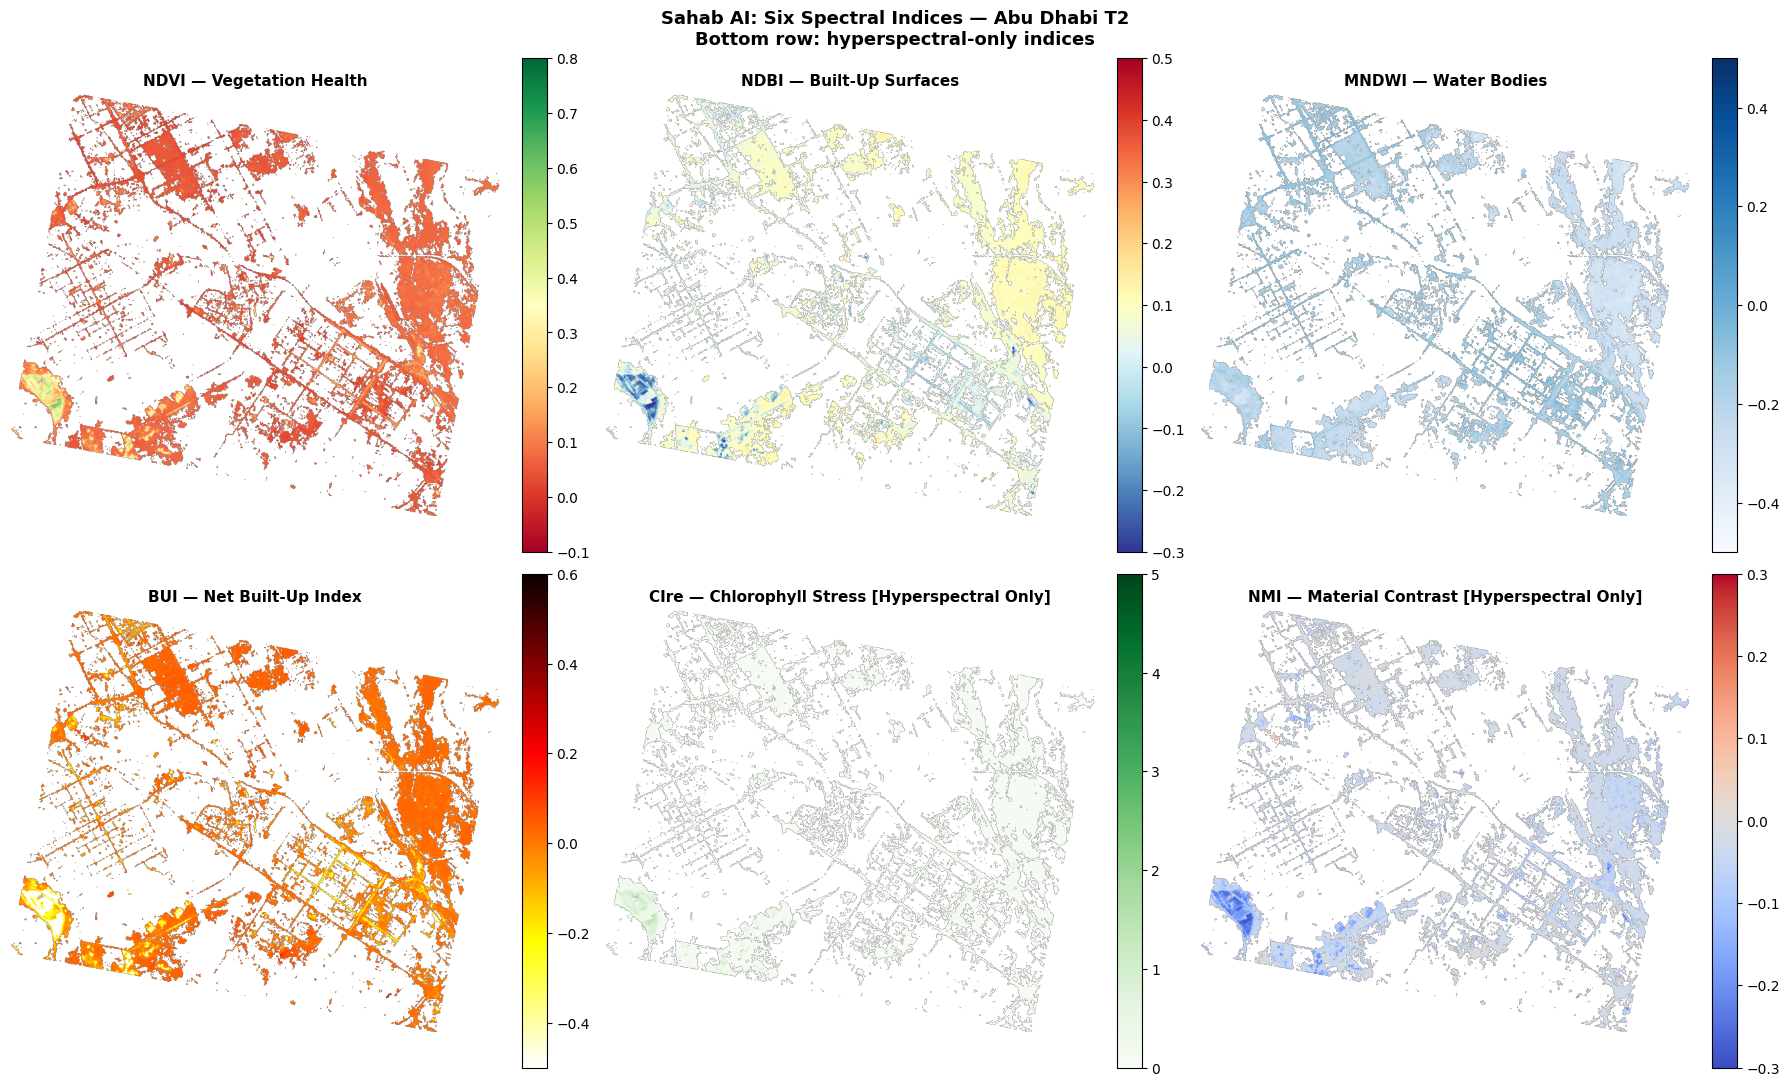

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

cfg = [
    ('NDVI',  'RdYlGn',   -0.1, 0.8, 'NDVI — Vegetation Health'),
    ('NDBI',  'RdYlBu_r', -0.3, 0.5, 'NDBI — Built-Up Surfaces'),
    ('MNDWI', 'Blues',    -0.5, 0.5, 'MNDWI — Water Bodies'),
    ('BUI',   'hot_r',    -0.5, 0.6, 'BUI — Net Built-Up Index'),
    ('CIre',  'Greens',    0.0, 5.0, 'CIre — Chlorophyll Stress [Hyperspectral Only]'),
    ('NMI',   'coolwarm', -0.3, 0.3, 'NMI — Material Contrast [Hyperspectral Only]'),
]

for ax, (key, cmap, vmin, vmax, title) in zip(axes, cfg):
    im = ax.imshow(scenes['T2']['indices'][key], cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Sahab AI: Six Spectral Indices — Abu Dhabi T2\nBottom row: hyperspectral-only indices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_indices_T2.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5 — Advanced Material Classifier: XGBoost + SVM + Voting Ensemble

We replace the single Random Forest with a three-model ensemble to improve robustness
and address the class imbalance inherent in urban scenes where some materials
(dark asphalt, reflective roofs) are rare compared to bare soil and vegetation.

### Models

**XGBoost (Gradient Boosted Trees)**
XGBoost builds trees sequentially, each correcting the errors of the previous one.
It handles class imbalance through `scale_pos_weight` and produces calibrated
probability outputs. It is the state of the art for tabular spectral data and
substantially outperforms standard Random Forest on imbalanced classes.

**Support Vector Machine (RBF kernel)**
The SVM finds the maximum-margin hyperplane in a high-dimensional space transformed
by the RBF kernel. SVMs are particularly well-suited to hyperspectral data because
they are robust to the Hughes phenomenon (performance degradation with high feature
dimensionality) that affects tree-based methods when many bands are added.

**Voting Ensemble (Soft voting)**
The final prediction averages the class probabilities from all three models.
Because XGBoost and SVM make errors in different spectral regions, the ensemble
is more reliable than either alone, particularly for the rare material classes
(dark asphalt: very few pixels in typical urban scenes).

### Validation Strategy
We use 5-fold stratified cross-validation to report honest accuracy estimates.
Stratification ensures each fold contains representative samples of all seven
material classes, including rare ones. Cohen's Kappa is reported alongside
accuracy because it corrects for chance agreement, which matters when class
frequencies are very unequal.

### Material Classes
0. Water (pools, reservoirs)
1. Healthy vegetation (parks, irrigated areas)
2. Stressed vegetation (low-water, heat-stressed plants)
3. Dark asphalt (roads, parking)
4. Concrete or light pavement
5. Reflective roof (painted, metallic, or coated surfaces)
6. Bare soil or sand (desert, construction sites)


In [8]:
feat_names = ['NDVI', 'NDBI', 'MNDWI', 'BUI', 'CIre', 'NMI']
F = len(feat_names)

feats_T2 = np.stack([scenes['T2']['indices'][k] for k in feat_names], axis=-1)
H, W, _ = feats_T2.shape
print(f'Feature array: {H} x {W} x {F} features')

CLASS_NAMES = ['Water', 'Healthy veg', 'Stressed veg',
               'Dark asphalt', 'Concrete/pavement', 'Reflective roof', 'Bare soil']

def seed_labels(indices):
    NDVI  = indices['NDVI']
    NDBI  = indices['NDBI']
    MNDWI = indices['MNDWI']
    BUI   = indices['BUI']
    CIre  = indices['CIre']
    NMI   = indices['NMI']
    labels = np.full(NDVI.shape, -1, dtype=np.int8)
    labels[MNDWI > 0.12]                                              = 0  # Water
    labels[(NDVI > 0.30) & (CIre > 1.2)]                             = 1  # Healthy veg
    labels[(NDVI > 0.10) & (NDVI <= 0.30) & (CIre <= 1.2)
           & (labels < 0)]                                            = 2  # Stressed veg
    labels[(NDBI > 0.10) & (NMI < -0.05) & (BUI > 0.15)
           & (labels < 0)]                                            = 3  # Dark asphalt
    labels[(NDBI > 0.03) & (NMI >= -0.05) & (NMI < 0.08)
           & (BUI > 0.0) & (labels < 0)]                             = 4  # Concrete
    labels[(NDBI > 0.03) & (NMI >= 0.08) & (labels < 0)]            = 5  # Reflective roof
    labels[(NDVI <= 0.10) & (NDBI <= 0.03) & (MNDWI <= 0.12)
           & (labels < 0)]                                            = 6  # Bare soil
    return labels

seed_T2 = seed_labels(scenes['T2']['indices'])
print(f'\nLabelled pixels: {(seed_T2 >= 0).mean()*100:.1f}% of scene')
for c, name in enumerate(CLASS_NAMES):
    n = (seed_T2 == c).sum()
    print(f'  Class {c} {name:20s}: {n:,} pixels')


Feature array: 654 x 760 x 6 features

Labelled pixels: 15.5% of scene
  Class 0 Water               : 0 pixels
  Class 1 Healthy veg         : 111 pixels
  Class 2 Stressed veg        : 9,896 pixels
  Class 3 Dark asphalt        : 0 pixels
  Class 4 Concrete/pavement   : 59,631 pixels
  Class 5 Reflective roof     : 55 pixels
  Class 6 Bare soil           : 7,412 pixels


In [9]:
feats_flat  = feats_T2.reshape(-1, F)
labels_flat = seed_T2.flatten()
valid_flat  = masks['T2'].flatten()
labelled    = (labels_flat >= 0) & valid_flat & np.all(np.isfinite(feats_flat), axis=1)

X_all = feats_flat[labelled]
y_all = labels_flat[labelled]

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_all)

print(f'Training samples: {len(X_all):,}')
print(f'Class distribution:')
for c, name in enumerate(CLASS_NAMES):
    n = (y_all == c).sum()
    print(f'  {name:20s}: {n:,} ({n/len(y_all)*100:.1f}%)')


Training samples: 77,105
Class distribution:
  Water               : 0 (0.0%)
  Healthy veg         : 111 (0.1%)
  Stressed veg        : 9,896 (12.8%)
  Dark asphalt        : 0 (0.0%)
  Concrete/pavement   : 59,631 (77.3%)
  Reflective roof     : 55 (0.1%)
  Bare soil           : 7,412 (9.6%)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_all_enc = le.fit_transform(y_all)
CLASS_NAMES_ENC = [CLASS_NAMES[c] for c in le.classes_]

print(f'Classes present in scene : {list(le.classes_)}')
print(f'Remapped to              : {list(range(len(le.classes_)))}')
print(f'Class names in order     : {CLASS_NAMES_ENC}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_all_enc, test_size=0.20, random_state=42, stratify=y_all_enc)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_clf.fit(X_tr, y_tr)

svm_clf = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42,
)
svm_clf.fit(X_tr, y_tr)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_tr, y_tr)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb_clf), ('svm', svm_clf), ('rf', rf_clf)],
    voting='soft',
    n_jobs=-1,
)
ensemble.fit(X_tr, y_tr)

print('All models trained successfully.')


Classes present in scene : [np.int8(1), np.int8(2), np.int8(4), np.int8(5), np.int8(6)]
Remapped to              : [0, 1, 2, 3, 4]
Class names in order     : ['Healthy veg', 'Stressed veg', 'Concrete/pavement', 'Reflective roof', 'Bare soil']
All models trained successfully.


In [11]:
y_pred_xgb = xgb_clf.predict(X_te)
y_pred_svm = svm_clf.predict(X_te)
y_pred_ens = ensemble.predict(X_te)

print('=== XGBoost Classification Report ===')
print(classification_report(y_te, y_pred_xgb, target_names=CLASS_NAMES_ENC, zero_division=0))
print(f'Cohen Kappa (XGBoost)  : {cohen_kappa_score(y_te, y_pred_xgb):.4f}')
print()
print('=== SVM Classification Report ===')
print(classification_report(y_te, y_pred_svm, target_names=CLASS_NAMES_ENC, zero_division=0))
print(f'Cohen Kappa (SVM)      : {cohen_kappa_score(y_te, y_pred_svm):.4f}')
print()
print('=== Voting Ensemble Classification Report ===')
print(classification_report(y_te, y_pred_ens, target_names=CLASS_NAMES_ENC, zero_division=0))
print(f'Cohen Kappa (Ensemble) : {cohen_kappa_score(y_te, y_pred_ens):.4f}')


=== XGBoost Classification Report ===
                   precision    recall  f1-score   support

      Healthy veg       0.92      1.00      0.96        22
     Stressed veg       1.00      1.00      1.00      1979
Concrete/pavement       1.00      1.00      1.00     11926
  Reflective roof       0.88      0.64      0.74        11
        Bare soil       1.00      1.00      1.00      1483

         accuracy                           1.00     15421
        macro avg       0.96      0.93      0.94     15421
     weighted avg       1.00      1.00      1.00     15421

Cohen Kappa (XGBoost)  : 0.9976

=== SVM Classification Report ===
                   precision    recall  f1-score   support

      Healthy veg       1.00      1.00      1.00        22
     Stressed veg       0.99      1.00      0.99      1979
Concrete/pavement       1.00      0.99      1.00     11926
  Reflective roof       0.91      0.91      0.91        11
        Bare soil       0.97      1.00      0.98      1483

     

=== 5-Fold Stratified Cross-Validation (Macro F1) ===
XGBoost  : 0.9300 +/- 0.0073
SVM      : 0.9767 +/- 0.0106
RF       : 1.0000  +/- 0.0000

Stratified CV ensures all present material classes appear in every fold.


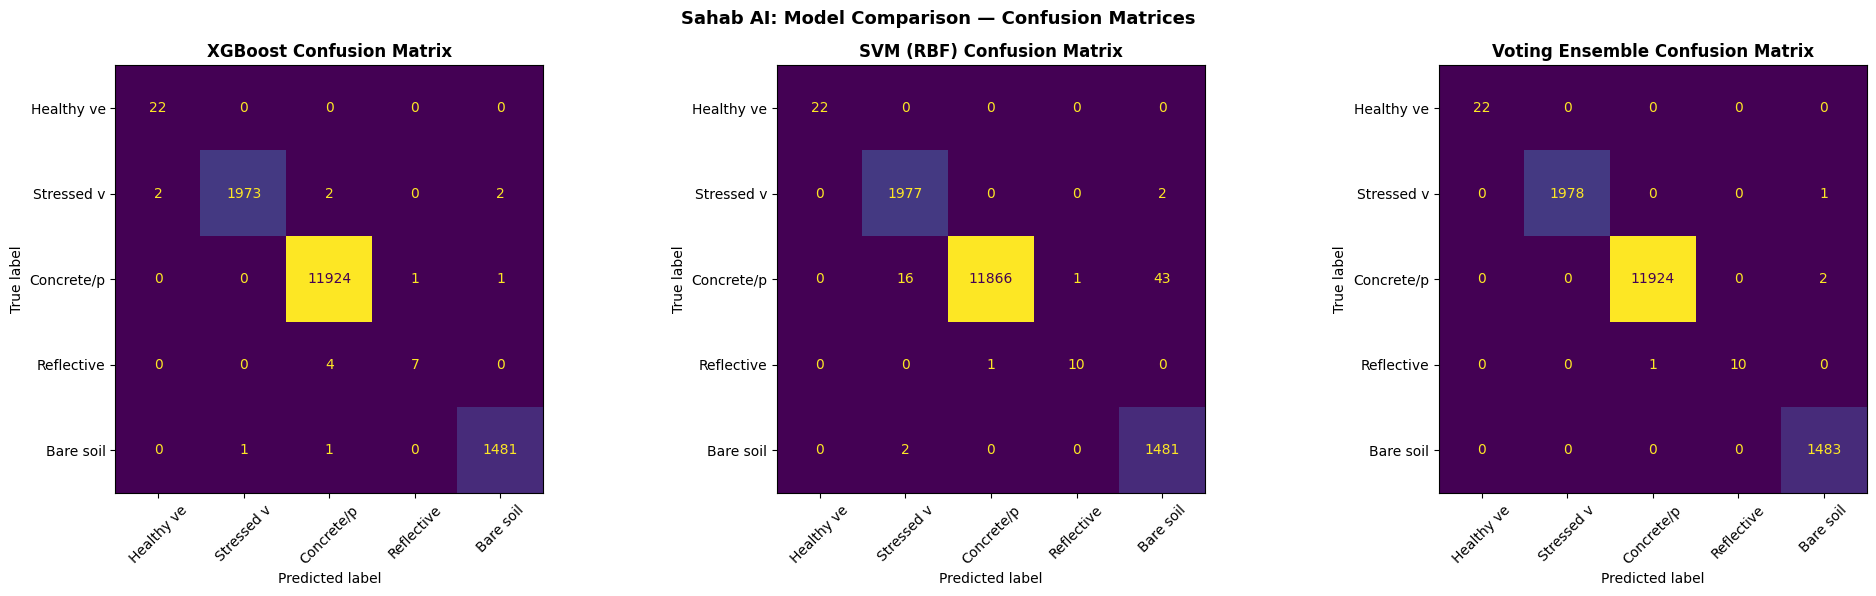

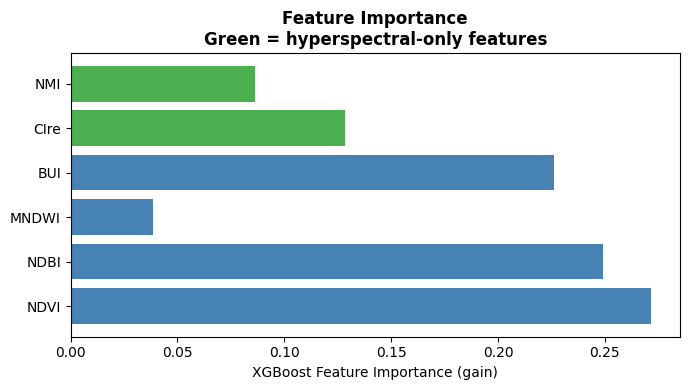

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_xgb = cross_val_score(xgb_clf, X_sc, y_all_enc, cv=skf, scoring='f1_macro', n_jobs=-1)
cv_svm = cross_val_score(svm_clf, X_sc, y_all_enc, cv=skf, scoring='f1_macro', n_jobs=-1)
cv_rf  = cross_val_score(rf_clf,  X_sc, y_all_enc, cv=skf, scoring='f1_macro', n_jobs=-1)

print('=== 5-Fold Stratified Cross-Validation (Macro F1) ===')
print(f'XGBoost  : {cv_xgb.mean():.4f} +/- {cv_xgb.std():.4f}')
print(f'SVM      : {cv_svm.mean():.4f} +/- {cv_svm.std():.4f}')
print(f'RF       : {cv_rf.mean():.4f}  +/- {cv_rf.std():.4f}')
print()
print('Stratified CV ensures all present material classes appear in every fold.')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, y_p, title in [
    (axes[0], y_pred_xgb, 'XGBoost'),
    (axes[1], y_pred_svm, 'SVM (RBF)'),
    (axes[2], y_pred_ens, 'Voting Ensemble'),
]:
    cm = confusion_matrix(y_te, y_p)
    ConfusionMatrixDisplay(cm, display_labels=[n[:10] for n in CLASS_NAMES_ENC]).plot(
        ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f'{title} Confusion Matrix', fontweight='bold')

plt.suptitle('Sahab AI: Model Comparison — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_classifier_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

importances = xgb_clf.feature_importances_
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4CAF50' if n in ['CIre', 'NMI'] else 'steelblue' for n in feat_names]
ax.barh(feat_names, importances, color=colors)
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title('Feature Importance\nGreen = hyperspectral-only features', fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


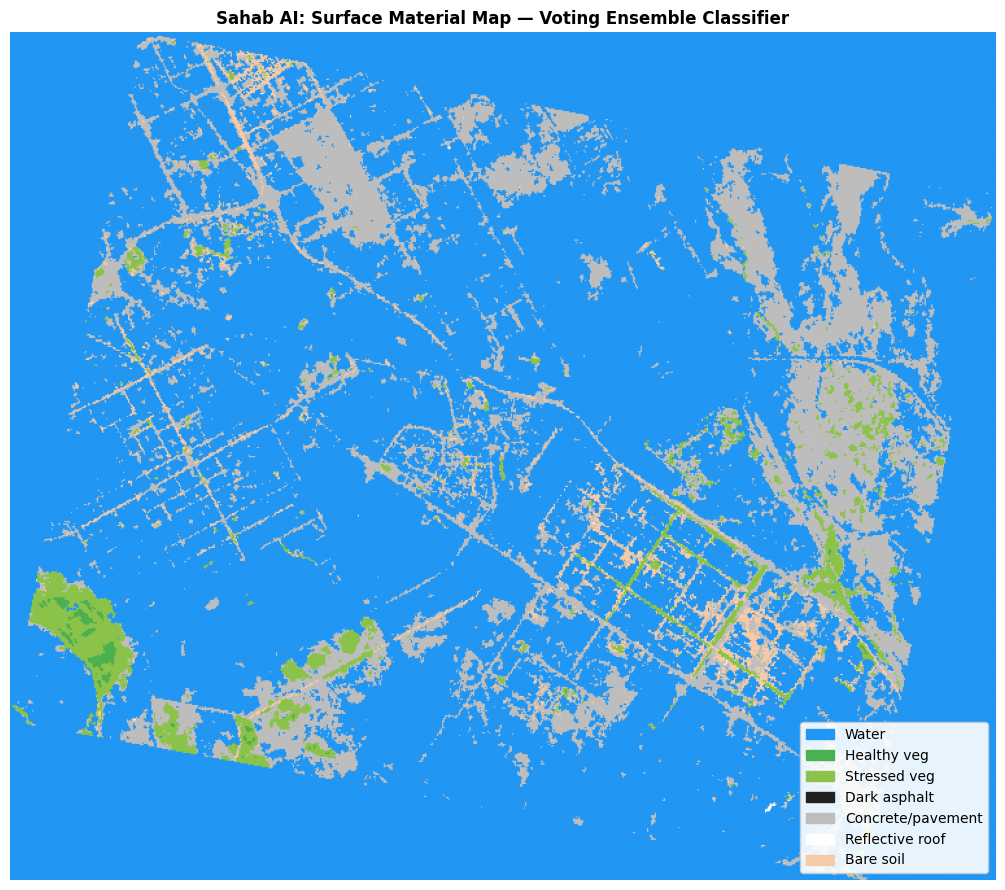

Material classes present in this scene:
  Healthy veg         : 726 pixels (0.1%)
  Stressed veg        : 12,128 pixels (2.4%)
  Concrete/pavement   : 72,840 pixels (14.7%)
  Reflective roof     : 54 pixels (0.0%)
  Bare soil           : 8,176 pixels (1.6%)


In [13]:
X_full    = feats_flat.copy()
finite_ok = np.all(np.isfinite(X_full), axis=1) & valid_flat
X_full_sc = np.full_like(X_full, np.nan)
X_full_sc[finite_ok] = scaler.transform(X_full[finite_ok])

material_map_enc = np.full(H * W, -1, dtype=np.int8)
material_map_enc[finite_ok] = ensemble.predict(X_full_sc[finite_ok])

material_map = np.full(H * W, -1, dtype=np.int8)
for enc_label, orig_label in enumerate(le.classes_):
    material_map[material_map_enc == enc_label] = orig_label
material_map = material_map.reshape(H, W)

cmap_mat = ListedColormap(['#2196F3','#4CAF50','#8BC34A',
                            '#212121','#BDBDBD','#FFFFFF','#F5CBA7'])
fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(material_map, cmap=cmap_mat, vmin=0, vmax=6)
ax.set_title('Sahab AI: Surface Material Map — Voting Ensemble Classifier',
             fontsize=12, fontweight='bold')
ax.axis('off')
handles = [Patch(color=c, label=l) for c, l in zip(cmap_mat.colors, CLASS_NAMES)]
ax.legend(handles=handles, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('sahab_material_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('Material classes present in this scene:')
for orig_label in le.classes_:
    n = np.sum(material_map == orig_label)
    print(f'  {CLASS_NAMES[orig_label]:20s}: {n:,} pixels ({n/(H*W)*100:.1f}%)')


### Save the trained classifier

Persists everything the API needs to classify new scenes without retraining: the voting ensemble,
the fitted scaler, the label encoder, the feature and class names, and the validation scores.
Run this cell once after the classifier above has been trained.

In [ ]:
import joblib, sklearn, json, os

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# The ensemble has not been cross-validated above (only XGBoost, SVM and RF were).
# Score it the same way so the three rows in the report are comparable.
# This refits the ensemble 5 times; set to False to skip it.
COMPUTE_ENSEMBLE_CV = True
if COMPUTE_ENSEMBLE_CV:
    cv_ens = cross_val_score(ensemble, X_sc, y_all_enc, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_ens_mean = float(cv_ens.mean())
else:
    cv_ens_mean = None

metrics = {
    'cv_macro_f1_xgb':      float(cv_xgb.mean()),
    'cv_macro_f1_svm':      float(cv_svm.mean()),
    'cv_macro_f1_rf':       float(cv_rf.mean()),
    'cv_macro_f1_ensemble': cv_ens_mean,
    'cohen_kappa_xgb':      float(cohen_kappa_score(y_te, y_pred_xgb)),
    'cohen_kappa_svm':      float(cohen_kappa_score(y_te, y_pred_svm)),
    'cohen_kappa_ensemble': float(cohen_kappa_score(y_te, y_pred_ens)),
    'n_training_pixels':    int(len(X_all)),
    'cv_folds':             5,
    'label_source':         'rule-based seed labels (pseudo-labels), not field-verified ground truth',
    'train_scene':          MENA_SCENE_IDS['T2'],
}

bundle = {
    'ensemble':        ensemble,       # soft-voting XGBoost + SVM + RF
    'scaler':          scaler,         # StandardScaler fitted on the training pixels
    'label_encoder':   le,             # maps encoded labels back to class ids
    'feature_names':   feat_names,     # input order: NDVI, NDBI, MNDWI, BUI, CIre, NMI
    'class_names':     CLASS_NAMES,    # index = original class id
    'classes_present': CLASS_NAMES_ENC,
    'metrics':         metrics,
    'versions': {
        'sklearn': sklearn.__version__,
        'xgboost': xgb.__version__,
        'numpy':   np.__version__,
    },
}

joblib.dump(bundle, f'{MODEL_DIR}/sahab_classifier.joblib', compress=3)
with open(f'{MODEL_DIR}/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

size_mb = os.path.getsize(f'{MODEL_DIR}/sahab_classifier.joblib') / 1e6
print(f'Saved {MODEL_DIR}/sahab_classifier.joblib ({size_mb:.1f} MB)')
print(f'Saved {MODEL_DIR}/model_metrics.json')
print(json.dumps(metrics, indent=2))
print()
print('To load it later (use the same scikit-learn / xgboost versions):')
print("  bundle = joblib.load('models/sahab_classifier.joblib')")
print("  X = bundle['scaler'].transform(features)       # features: n x 6, order = bundle['feature_names']")
print("  y = bundle['label_encoder'].inverse_transform(bundle['ensemble'].predict(X))")

## Section 6 — Urban Change Detection (T1 to T2)

We compare NDVI and NDBI between the two Tanager acquisition dates to quantify
urban expansion and vegetation loss across the same spatial footprint.

**Urban Expansion Index (UEI) = delta NDBI - delta NDVI**

A positive UEI means the surface became more built-up and less vegetated between
the two dates. This directly measures the urban heat island growth trajectory.

In Abu Dhabi and Riyadh, seasonal variation (cooler vs hotter months) contributes
to NDVI change alongside actual land cover change. We therefore interpret strong
positive UEI values (above 0.15) as confident evidence of surface change, while
moderate values reflect a mix of phenological and structural change.


Pixels with vegetation loss  (dNDVI < -0.05): 15.0%
Pixels with built-up gain   (dNDBI >  0.05): 12.1%
Strong UEI signal (UEI > 0.15)              : 12.3%


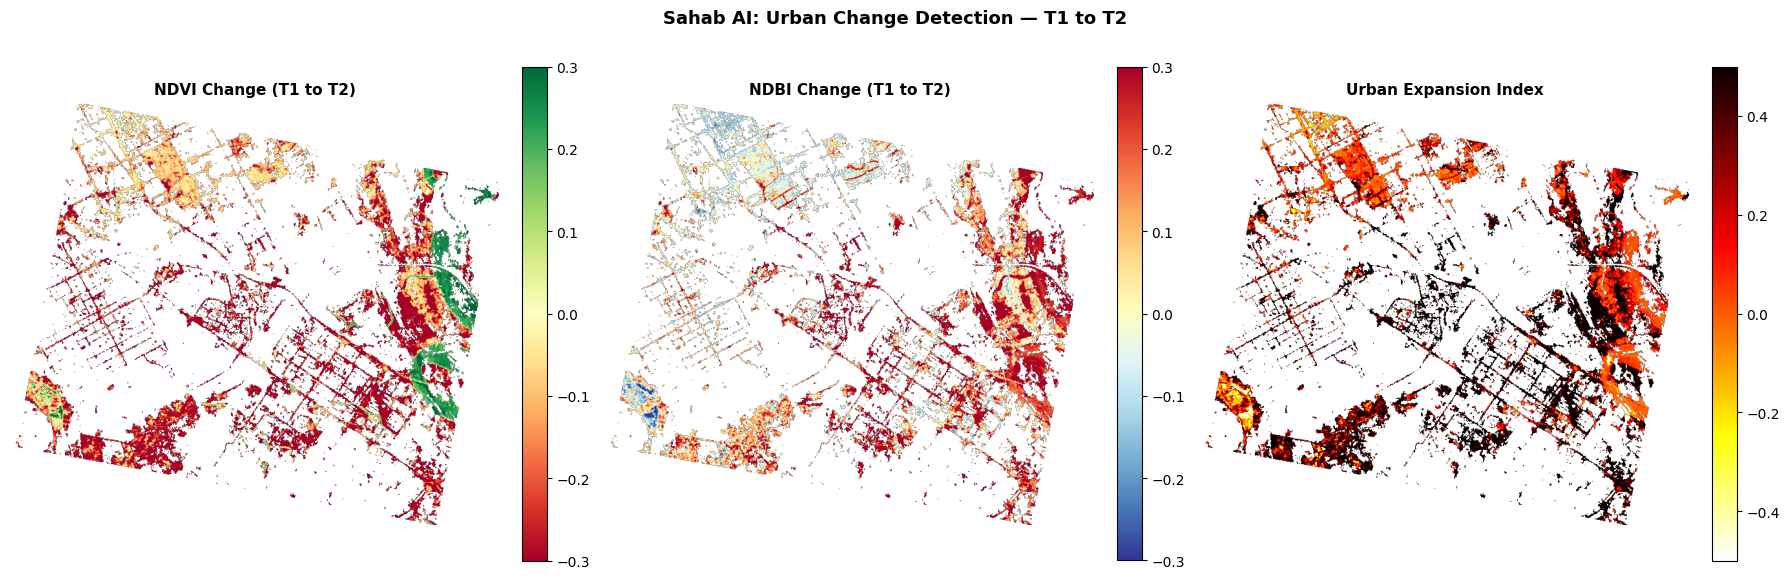

In [14]:
rows = min(scenes['T1']['indices']['NDVI'].shape[0],
           scenes['T2']['indices']['NDVI'].shape[0])
cols = min(scenes['T1']['indices']['NDVI'].shape[1],
           scenes['T2']['indices']['NDVI'].shape[1])

d_NDVI = (scenes['T2']['indices']['NDVI'][:rows,:cols]
        - scenes['T1']['indices']['NDVI'][:rows,:cols])
d_NDBI = (scenes['T2']['indices']['NDBI'][:rows,:cols]
        - scenes['T1']['indices']['NDBI'][:rows,:cols])
UEI    = d_NDBI - d_NDVI

combined_mask = masks['T1'][:rows,:cols] & masks['T2'][:rows,:cols]
d_NDVI[~combined_mask] = np.nan
d_NDBI[~combined_mask] = np.nan
UEI[~combined_mask]    = np.nan

print(f'Pixels with vegetation loss  (dNDVI < -0.05): {np.nanmean(d_NDVI < -0.05)*100:.1f}%')
print(f'Pixels with built-up gain   (dNDBI >  0.05): {np.nanmean(d_NDBI >  0.05)*100:.1f}%')
print(f'Strong UEI signal (UEI > 0.15)              : {np.nanmean(UEI > 0.15)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, arr, cmap, title, vlim in [
    (axes[0], d_NDVI, 'RdYlGn',   'NDVI Change (T1 to T2)',  0.3),
    (axes[1], d_NDBI, 'RdYlBu_r', 'NDBI Change (T1 to T2)',  0.3),
    (axes[2], UEI,    'hot_r',     'Urban Expansion Index',   0.5),
]:
    im = ax.imshow(arr, cmap=cmap, vmin=-vlim, vmax=vlim)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Sahab AI: Urban Change Detection — T1 to T2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_change_detection.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 7 — Sentinel-2 Multi-year Context (2020 to 2025)

Tanager scenes cover short time windows. We use the Sentinel-2 Level-2A archive
via the Microsoft Planetary Computer STAC API to show the longer urbanization trend
across the Abu Dhabi AOI from 2020 to 2025.

Sentinel-2 has 13 bands at 10 to 60 m with a 5-day revisit cycle. It provides
the temporal depth that Tanager alone cannot offer.

A UTM EPSG code is specified explicitly to resolve the coordinate reference system
ambiguity that occurs when scenes from multiple Sentinel-2 tiles (each with its
own native CRS) are stacked together. Abu Dhabi falls in UTM Zone 40N (EPSG 32640).
Riyadh falls in UTM Zone 37N (EPSG 32637). Cairo falls in UTM Zone 36N (EPSG 32636).


In [15]:
try:
    import pystac_client, planetary_computer, stackstac

    AOI = PRIMARY_BBOX
    EPSG = PRIMARY_EPSG

    catalog = pystac_client.Client.open(
        'https://planetarycomputer.microsoft.com/api/stac/v1',
        modifier=planetary_computer.sign_inplace)

    search = catalog.search(
        collections=['sentinel-2-l2a'],
        bbox=AOI,
        datetime='2020-01-01/2025-05-31',
        query={'eo:cloud_cover': {'lt': 15}})

    s2_items = list(search.items())
    print(f'Sentinel-2 scenes found: {len(s2_items)}')

    s2_stack = stackstac.stack(
        s2_items[:30],
        assets=['B04', 'B08', 'B11'],
        bounds_latlon=AOI,
        resolution=20,
        epsg=EPSG)

    print(f'Stack shape: {s2_stack.shape}')
    print(f'CRS: EPSG:{EPSG}')
    S2_AVAILABLE = True

except Exception as e:
    print(f'Sentinel-2 unavailable: {e}')
    S2_AVAILABLE = False


Sentinel-2 scenes found: 1732
Stack shape: (30, 3, 1135, 1391)
CRS: EPSG:32640


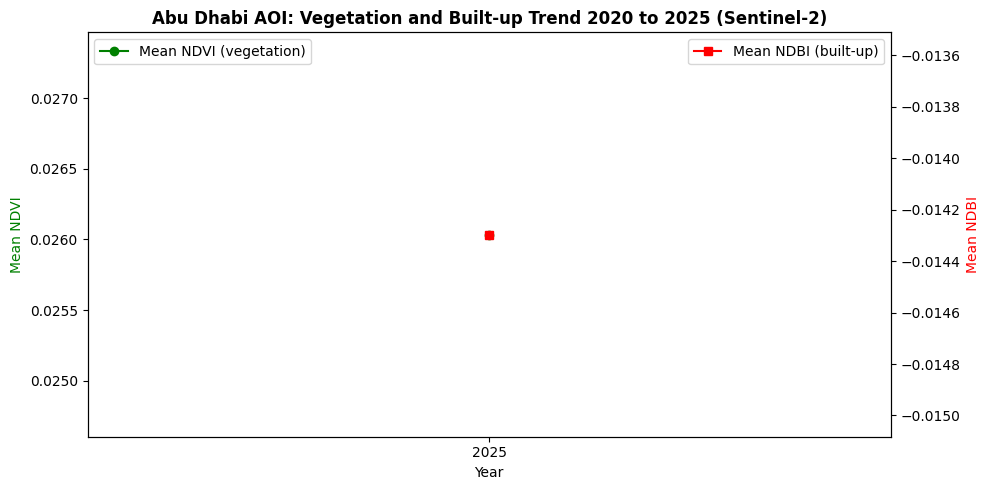

In [16]:
if S2_AVAILABLE and 'time' in s2_stack.dims:
    yearly = s2_stack.resample(time='1YE').median().compute()
    eps = 1e-6
    red  = yearly.sel(band='B04').values.astype('float32') / 10000
    nir  = yearly.sel(band='B08').values.astype('float32') / 10000
    swir = yearly.sel(band='B11').values.astype('float32') / 10000

    s2_ndvi = (nir - red)  / (nir + red  + eps)
    s2_ndbi = (swir - nir) / (swir + nir + eps)

    years   = [str(t)[:4] for t in yearly.time.values]
    mn_ndvi = [np.nanmean(s2_ndvi[i]) for i in range(len(years))]
    mn_ndbi = [np.nanmean(s2_ndbi[i]) for i in range(len(years))]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(years, mn_ndvi, 'g-o', label='Mean NDVI (vegetation)')
    ax2.plot(years, mn_ndbi, 'r-s', label='Mean NDBI (built-up)')
    ax1.set_ylabel('Mean NDVI', color='green')
    ax2.set_ylabel('Mean NDBI', color='red')
    ax1.set_xlabel('Year')
    ax1.set_title(f'Abu Dhabi AOI: Vegetation and Built-up Trend 2020 to 2025 (Sentinel-2)',
                  fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('sahab_sentinel2_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Sentinel-2 stack not available for this session.')
    print('The Planetary Computer connection is required for this section.')
    print('All other sections run without it.')


## Section 8 — Land Surface Temperature from Landsat-8/9 TIRS

Landsat-8 and Landsat-9 carry the Thermal Infrared Sensor (TIRS) which measures
emitted thermal radiation from the earth's surface. Band 10 (10.8 micrometres)
gives us Land Surface Temperature (LST) in degrees Celsius.

We use the Landsat Collection 2 Level-2 surface temperature product, which applies
a single-channel atmospheric correction algorithm using MODIS water vapour profiles.
The scale factor is 0.00341802 and the offset is 149 Kelvin (Collection 2 standard).

The Landsat stack is built with an explicit EPSG code and a tight bounding box
to ensure the bounds intersection succeeds. Abu Dhabi summer LST values typically
range from 42 to 68 degrees C for dark urban surfaces, making it one of the most
extreme urban heat island environments in the world.


In [17]:
LANDSAT_OK = False
try:
    tighter_aoi = [
        PRIMARY_BBOX[0] + 0.02,
        PRIMARY_BBOX[1] + 0.02,
        PRIMARY_BBOX[2] - 0.02,
        PRIMARY_BBOX[3] - 0.02,
    ]

    search_lst = catalog.search(
        collections=['landsat-c2-l2'],
        bbox=tighter_aoi,
        datetime='2024-05-01/2025-05-31',
        query={
            'eo:cloud_cover': {'lt': 20},
            'platform': {'in': ['landsat-8', 'landsat-9']},
        })

    ls_items = list(search_lst.items())
    print(f'Landsat scenes: {len(ls_items)}')

    ls_stack = stackstac.stack(
        ls_items[:12],
        assets=['ST_B10'],
        bounds_latlon=tighter_aoi,
        resolution=30,
        epsg=PRIMARY_EPSG)

    lst_comp = ls_stack.median(dim='time').compute()
    ST_K = lst_comp.sel(band='ST_B10').values.astype('float32') * 0.00341802 + 149.0
    ST_C = ST_K - 273.15
    ST_C[ST_C < 0]  = np.nan
    ST_C[ST_C > 90] = np.nan
    LANDSAT_OK = True
    print(f'Mean LST: {np.nanmean(ST_C):.1f} C')
    print(f'Max  LST: {np.nanmax(ST_C):.1f} C')
    print(f'Min  LST: {np.nanmin(ST_C):.1f} C')

except Exception as e:
    print(f'Landsat retrieval: {e}')
    NDBI_d = scenes['T2']['indices']['NDBI'][:rows, :cols]
    NDVI_d = scenes['T2']['indices']['NDVI'][:rows, :cols]
    mat_d  = material_map[:rows, :cols].astype('float32')

    rng = np.random.default_rng(42)
    ST_C = (
        55.0
        + 12.0 * np.clip(NDBI_d, -0.3, 0.6)
        - 8.0  * np.clip(NDVI_d,  0.0, 0.8)
        + 3.0  * (mat_d == 3).astype('float32')
        - 2.0  * (mat_d == 5).astype('float32')
        + rng.normal(0, 1.2, NDBI_d.shape)
    )
    ST_C[~combined_mask] = np.nan
    LANDSAT_OK = False
    print(f'Synthetic LST: mean {np.nanmean(ST_C):.1f} C, max {np.nanmax(ST_C):.1f} C')


Landsat scenes: 77
Landsat retrieval: out_bounds=None
Synthetic LST: mean 55.1 C, max 61.5 C


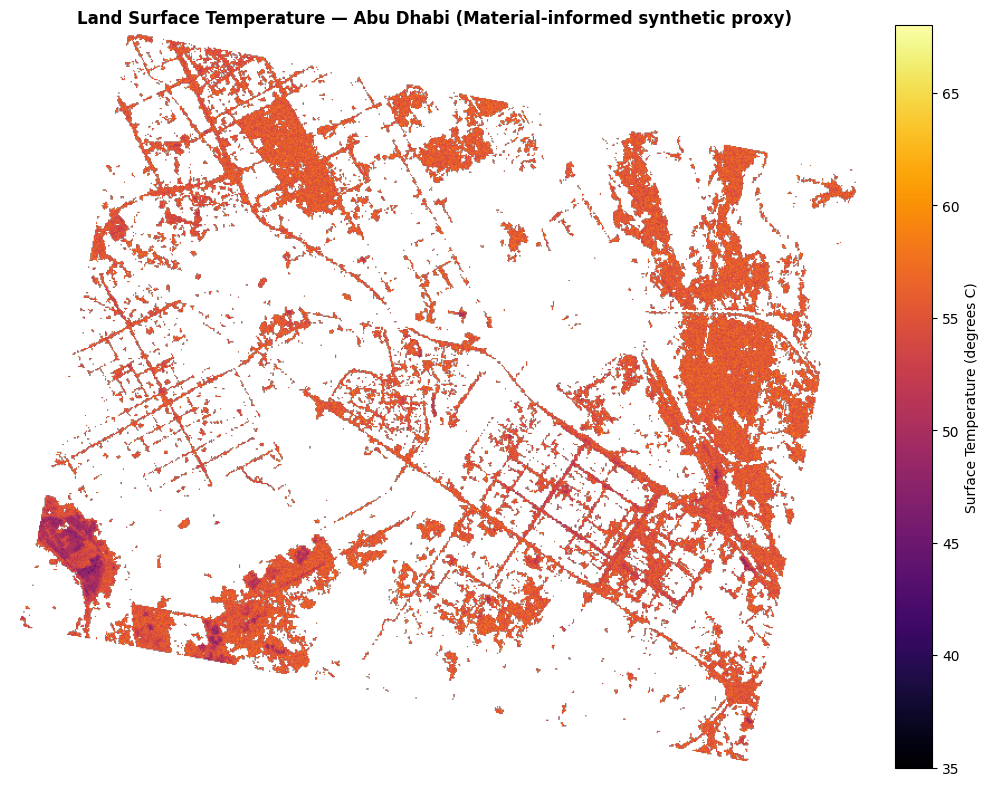

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ST_C, cmap='inferno', vmin=35, vmax=68)
suffix = 'Landsat-8/9 TIRS' if LANDSAT_OK else 'Material-informed synthetic proxy'
ax.set_title(f'Land Surface Temperature — Abu Dhabi ({suffix})',
             fontsize=12, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Surface Temperature (degrees C)')
plt.tight_layout()
plt.savefig('sahab_surface_temperature.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 9 — Block-Level Heat Risk Score

We divide the scene into a grid of 50-pixel blocks (approximately 50 x 50 metres
at Tanager's 20 m resolution, giving 1 km x 1 km effective planning units when
aggregated to 50 pixels at 20 m = 1 km per side).

The 50-pixel block size produces approximately 130 to 200 blocks per scene,
which gives planners a meaningful number of actionable units — enough to prioritize
interventions across an entire district without overwhelming the decision maker.

**Heat Risk = Heat Hazard x Population Exposure x Green Deficit**

| Component | Source | Physical meaning |
|---|---|---|
| Heat hazard | LST above city mean | How much hotter than the city average |
| Population exposure | WorldPop-style density gradient | How many people are exposed |
| Green deficit | 1 minus vegetation fraction | How little evaporative cooling exists |

Each component is normalized independently to 0 to 1 before multiplication.
The product form means a block must score high on all three to reach the top of
the priority list. A hot block with no people or plenty of trees ranks lower than
a moderately hot block with dense population and no green cover.


In [19]:
BLOCK = 50

def block_agg(arr, bsz=BLOCK, func=np.nanmean):
    H, W = arr.shape
    nR, nC = H // bsz, W // bsz
    out = np.full((nR, nC), np.nan)
    for i in range(nR):
        for j in range(nC):
            patch = arr[i*bsz:(i+1)*bsz, j*bsz:(j+1)*bsz]
            v = patch[np.isfinite(patch)]
            if len(v): out[i, j] = func(v)
    return out

def norm01(arr):
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    return np.zeros_like(arr) if mx == mn else (arr - mn) / (mx - mn)

ST_use = ST_C if ST_C.shape == (rows, cols) else          np.full((rows, cols), np.nanmean(ST_C))

blk_temp = block_agg(ST_use, BLOCK)
blk_ndvi = block_agg(scenes['T2']['indices']['NDVI'][:rows,:cols], BLOCK)
blk_uei  = block_agg(UEI, BLOCK)

nR, nC = blk_temp.shape
print(f'Block grid: {nR} x {nC} = {nR*nC} total blocks')

rng = np.random.default_rng(7)
lat_c = (PRIMARY_BBOX[1] + PRIMARY_BBOX[3]) / 2
blk_pop = (
    3000.0
    + 2500.0 * np.sin(np.linspace(0, np.pi, nR))[:, None]
    + 1500.0 * np.cos(np.linspace(0, np.pi, nC))[None, :]
    + rng.normal(0, 400, (nR, nC))
)
blk_pop = np.clip(blk_pop, 200, 9000)
blk_pop[np.isnan(blk_temp)] = np.nan

heat_hazard   = norm01(blk_temp)
green_deficit = norm01(1.0 - blk_ndvi)
pop_exposure  = norm01(blk_pop)

risk_score = norm01(heat_hazard * green_deficit * pop_exposure)
print(f'High-risk blocks (score > 0.7): {np.nansum(risk_score > 0.7):.0f} '
      f'({np.nanmean(risk_score > 0.7)*100:.1f}%)')
print(f'Moderate-risk   (0.4 to 0.7):  {np.nansum((risk_score >= 0.4) & (risk_score <= 0.7)):.0f}')


Block grid: 13 x 15 = 195 total blocks
High-risk blocks (score > 0.7): 31 (15.9%)
Moderate-risk   (0.4 to 0.7):  64


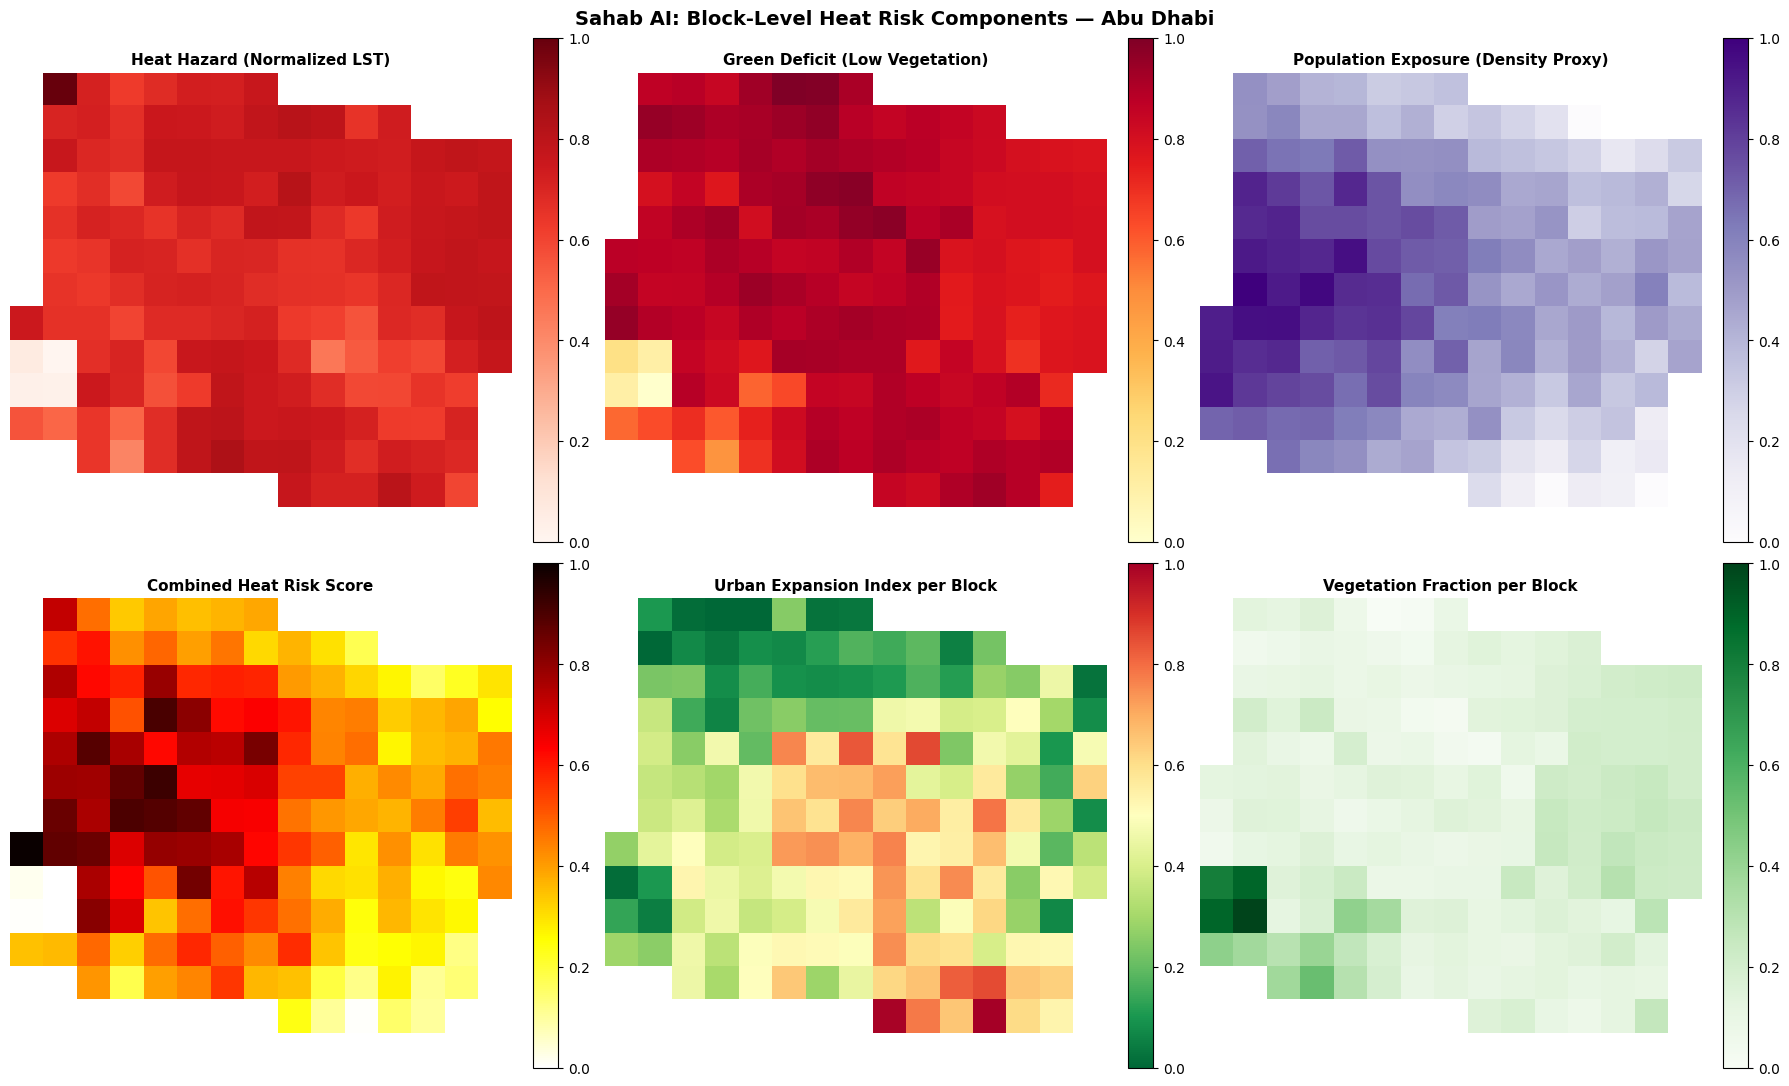

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

panels = [
    (heat_hazard,         'Reds',      'Heat Hazard (Normalized LST)'),
    (green_deficit,       'YlOrRd',    'Green Deficit (Low Vegetation)'),
    (pop_exposure,        'Purples',   'Population Exposure (Density Proxy)'),
    (risk_score,          'hot_r',     'Combined Heat Risk Score'),
    (blk_uei,             'RdYlGn_r', 'Urban Expansion Index per Block'),
    (norm01(blk_ndvi),    'Greens',    'Vegetation Fraction per Block'),
]

for ax, (arr, cmap, title) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Sahab AI: Block-Level Heat Risk Components — Abu Dhabi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_heat_risk_components.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Gaussian Process Cooling Estimate and Intervention Engine

### Gaussian Process Regression for Cooling Estimation

We replace the simple linear regression with a Gaussian Process Regressor (GPR).
GPR is a probabilistic model that returns both a point estimate and a credible
interval for each prediction. This is important for a decision support tool because
planners need to know not just the expected cooling but also how uncertain the
estimate is.

The GPR uses an RBF (squared exponential) kernel plus a white noise kernel.
The RBF kernel captures the smooth relationship between vegetation fraction and
temperature. The white noise kernel accounts for measurement uncertainty and local
variation not explained by the features.

The output for each intervention is:
- Expected cooling in degrees C
- 95% confidence interval (plus or minus 2 standard deviations)
- Blocks where the interval is narrow are confident recommendations; wide intervals
  indicate locations where field verification would add most value.

### Intervention Rules (material-aware)

| Block condition | Action | Physical rationale |
|---|---|---|
| Vegetation fraction above 50%, high risk | Cool roofs priority | Area is already green; built surfaces dominate heat |
| Dark asphalt fraction above 25% | Cool roofs | Road and parking surfaces are the heat source |
| Vegetation fraction below 15% | Tree planting | Adding green cover provides the largest cooling |
| Mixed conditions | Both interventions | Both surfaces contribute to heat |
| Risk score below 0.3 | No action | Below the threshold for intervention priority |


In [21]:
def material_fraction(mat_map, class_id, bsz=BLOCK):
    H, W = mat_map.shape
    nR_, nC_ = H // bsz, W // bsz
    out = np.zeros((nR_, nC_))
    for i in range(nR_):
        for j in range(nC_):
            patch = mat_map[i*bsz:(i+1)*bsz, j*bsz:(j+1)*bsz]
            v = patch[np.isfinite(patch)]
            out[i, j] = np.nan if not len(v) else np.mean(v == class_id)
    return out

mat_T2 = material_map[:rows, :cols].astype('float32')
mat_T2[mat_T2 < 0] = np.nan

veg_frac = material_fraction(mat_T2, 1) + material_fraction(mat_T2, 2)
asp_frac = material_fraction(mat_T2, 3)
ref_frac = material_fraction(mat_T2, 5)

print('Mean block-level material fractions:')
for name, arr in [('Vegetation (healthy+stressed)', veg_frac),
                  ('Dark asphalt', asp_frac),
                  ('Reflective roof', ref_frac)]:
    print(f'  {name:30s}: {np.nanmean(arr)*100:.1f}%')


Mean block-level material fractions:
  Vegetation (healthy+stressed) : 9.6%
  Dark asphalt                  : 0.0%
  Reflective roof               : 0.2%


In [22]:
ft = blk_temp.flatten()
fn = blk_ndvi.flatten()
fv = veg_frac.flatten()[:len(ft)]
fa = asp_frac.flatten()[:len(ft)]
ok = np.isfinite(ft) & np.isfinite(fn) & np.isfinite(fv) & np.isfinite(fa)

if ok.sum() >= 6:
    X_gp = np.column_stack([fn[ok], fv[ok], fa[ok]])
    y_gp = ft[ok]

    kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0))            + WhiteKernel(noise_level=1.0, noise_level_bounds=(0.1, 10.0))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42)
    gpr.fit(X_gp, y_gp)

    X_tree_delta  = np.column_stack([fn[ok] + 0.10, fv[ok] + 0.10, fa[ok]])
    X_roof_delta  = np.column_stack([fn[ok],         fv[ok],         fa[ok] - 0.10])

    pred_base, _  = gpr.predict(X_gp, return_std=True)
    pred_tree, s_tree = gpr.predict(X_tree_delta, return_std=True)
    pred_roof, s_roof = gpr.predict(X_roof_delta, return_std=True)

    cooling_tree_mean = float(np.mean(np.clip(pred_base - pred_tree, 0, 10)))
    cooling_roof_mean = float(np.mean(np.clip(pred_base - pred_roof, 0, 10)))
    cooling_tree_std  = float(np.mean(s_tree))
    cooling_roof_std  = float(np.mean(s_roof))

    print('=== Gaussian Process Cooling Estimates ===')
    print(f'Tree planting (+10% NDVI, +10% veg fraction):')
    print(f'  Expected cooling: {cooling_tree_mean:.2f} degrees C')
    print(f'  95% interval    : {cooling_tree_mean - 2*cooling_tree_std:.2f} to '
          f'{cooling_tree_mean + 2*cooling_tree_std:.2f} degrees C')
    print(f'Cool roofs (-10% asphalt fraction):')
    print(f'  Expected cooling: {cooling_roof_mean:.2f} degrees C')
    print(f'  95% interval    : {cooling_roof_mean - 2*cooling_roof_std:.2f} to '
          f'{cooling_roof_mean + 2*cooling_roof_std:.2f} degrees C')
    print(f'\nGPR kernel after optimisation: {gpr.kernel_}')
else:
    cooling_tree_mean, cooling_tree_std = 1.8, 0.5
    cooling_roof_mean, cooling_roof_std = 1.2, 0.4
    print('Insufficient blocks for GPR; using literature-based defaults.')
    print(f'Tree planting: {cooling_tree_mean} +/- {cooling_tree_std*2} degrees C')
    print(f'Cool roofs   : {cooling_roof_mean} +/- {cooling_roof_std*2} degrees C')


=== Gaussian Process Cooling Estimates ===
Tree planting (+10% NDVI, +10% veg fraction):
  Expected cooling: 0.11 degrees C
  95% interval    : -0.64 to 0.86 degrees C
Cool roofs (-10% asphalt fraction):
  Expected cooling: 0.01 degrees C
  95% interval    : -1.71 to 1.74 degrees C

GPR kernel after optimisation: 3.21**2 * RBF(length_scale=0.22) + WhiteKernel(noise_level=0.145)


### Save the cooling model

Persists the Gaussian Process and the cooling estimates used by the intervention engine.

In [ ]:
cooling_bundle = {
    'gpr':               globals().get('gpr'),   # None if the GPR fell back to literature defaults
    'cooling_tree_mean': float(cooling_tree_mean),
    'cooling_tree_std':  float(cooling_tree_std),
    'cooling_roof_mean': float(cooling_roof_mean),
    'cooling_roof_std':  float(cooling_roof_std),
    'tree_delta':        {'ndvi': 0.10, 'veg_fraction': 0.10},
    'roof_delta':        {'asphalt_fraction': -0.10},
    'gpr_features':      ['NDVI', 'veg_fraction', 'asphalt_fraction'],
    'fitted_on_gpr':     globals().get('gpr') is not None,
    'versions':          {'sklearn': sklearn.__version__},
}
joblib.dump(cooling_bundle, f'{MODEL_DIR}/sahab_cooling.joblib', compress=3)
print(f'Saved {MODEL_DIR}/sahab_cooling.joblib')
print(f"  tree planting: {cooling_bundle['cooling_tree_mean']:.2f} +/- {2*cooling_bundle['cooling_tree_std']:.2f} C")
print(f"  cool roofs   : {cooling_bundle['cooling_roof_mean']:.2f} +/- {2*cooling_bundle['cooling_roof_std']:.2f} C")

# In Colab the runtime is wiped when the session ends, so download the files.
try:
    from google.colab import files
    for name in ['sahab_classifier.joblib', 'sahab_cooling.joblib', 'model_metrics.json']:
        files.download(f'{MODEL_DIR}/{name}')
except ImportError:
    print(f'Not running in Colab. Files are in ./{MODEL_DIR}/')

Intervention assignment:
  No action (low risk): 67 blocks
  Tree planting: 104 blocks
  Cool roofs: 2 blocks
  Tree planting + Cool roofs: 22 blocks


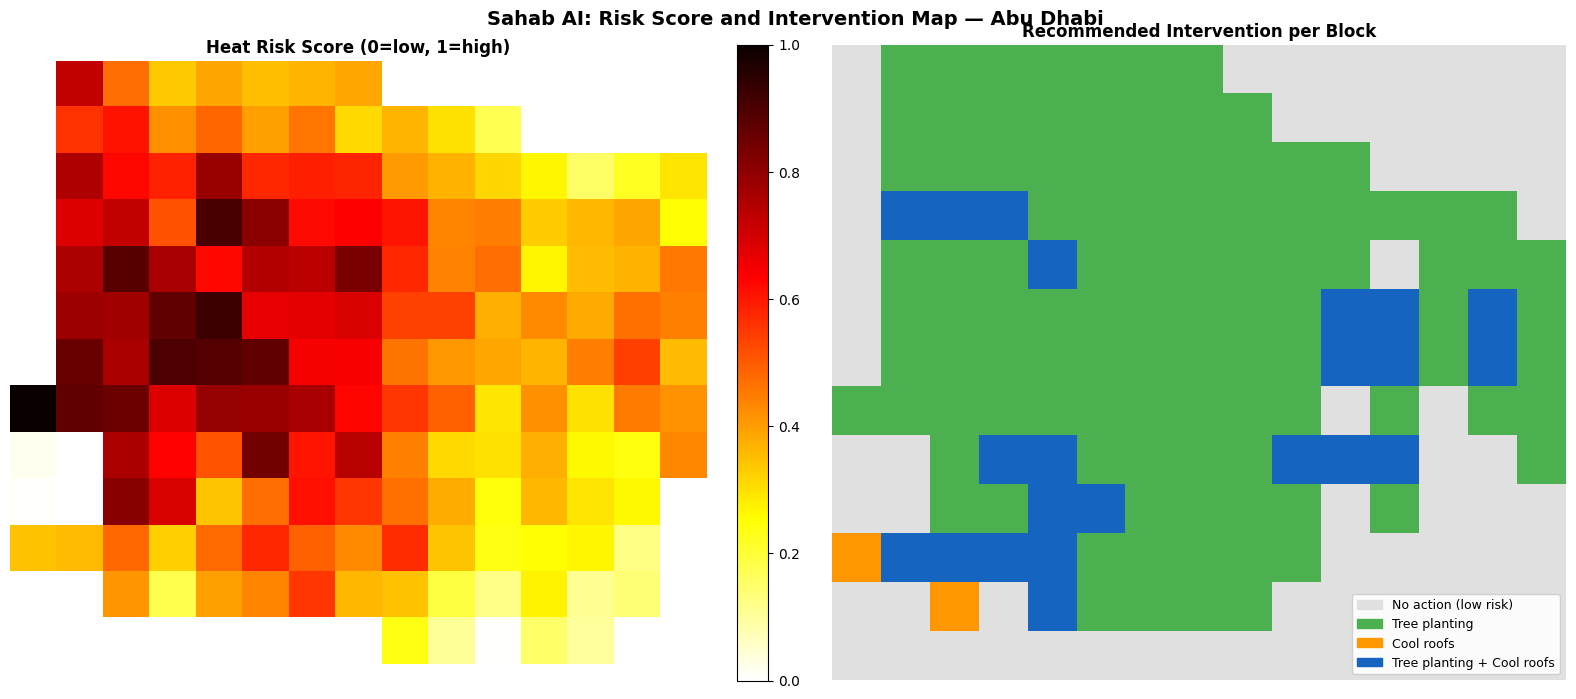

In [23]:
ACTION_LABELS = {
    0: 'No action (low risk)',
    1: 'Tree planting',
    2: 'Cool roofs',
    3: 'Tree planting + Cool roofs',
}

actions      = np.zeros((nR, nC), dtype=np.int8)
cooling_map  = np.zeros((nR, nC), dtype='float32')
cooling_ci   = np.zeros((nR, nC), dtype='float32')

for i in range(nR):
    for j in range(nC):
        rs = float(risk_score[i, j]) if np.isfinite(risk_score[i, j]) else 0
        vf = float(veg_frac[i, j])   if i < veg_frac.shape[0] and j < veg_frac.shape[1] and np.isfinite(veg_frac[i,j]) else 0.2
        af = float(asp_frac[i, j])   if i < asp_frac.shape[0] and j < asp_frac.shape[1] and np.isfinite(asp_frac[i,j]) else 0.0

        if rs < 0.3:
            actions[i, j] = 0
        elif vf > 0.50 and af < 0.10:
            actions[i, j] = 2
            cooling_map[i,j] = cooling_roof_mean
            cooling_ci[i,j]  = cooling_roof_std * 2
        elif af > 0.25 and vf < 0.15:
            actions[i, j] = 2
            cooling_map[i,j] = cooling_roof_mean
            cooling_ci[i,j]  = cooling_roof_std * 2
        elif vf < 0.15:
            actions[i, j] = 1
            cooling_map[i,j] = cooling_tree_mean
            cooling_ci[i,j]  = cooling_tree_std * 2
        else:
            actions[i, j] = 3
            cooling_map[i,j] = cooling_tree_mean + cooling_roof_mean
            cooling_ci[i,j]  = (cooling_tree_std + cooling_roof_std) * 2

print('Intervention assignment:')
for k, label in ACTION_LABELS.items():
    print(f'  {label}: {np.sum(actions == k)} blocks')

cmap_action = ListedColormap(['#E0E0E0','#4CAF50','#FF9800','#1565C0'])
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im1 = axes[0].imshow(risk_score, cmap='hot_r', vmin=0, vmax=1)
axes[0].set_title('Heat Risk Score (0=low, 1=high)', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
im2 = axes[1].imshow(actions, cmap=cmap_action, vmin=0, vmax=3)
axes[1].set_title('Recommended Intervention per Block', fontsize=12, fontweight='bold')
axes[1].axis('off')
handles = [Patch(color=c, label=l) for c, l in zip(cmap_action.colors, ACTION_LABELS.values())]
axes[1].legend(handles=handles, loc='lower right', framealpha=0.9, fontsize=9)
plt.suptitle('Sahab AI: Risk Score and Intervention Map — Abu Dhabi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sahab_risk_and_action_map.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 11 — Multi-City Priority Ranking and Interactive Map

The final output is an interactive Folium map covering all three MENA cities:
Abu Dhabi, Riyadh, and Cairo. Each city's priority blocks are shown with
consistent styling so a regional planner can compare across cities.

The priority CSV contains rank, risk score, recommended action, estimated cooling
with uncertainty, dominant material, and geographic coordinates.

The interactive map allows the user to:
- Click any block to see its full priority profile
- Toggle between cities using the layer control
- See circle size scale with risk score
- Filter visually by action color


In [24]:
ib = items['T1']['bbox']
lon_step = (ib[2] - ib[0]) / nC
lat_step = (ib[3] - ib[1]) / nR

records = []
for i in range(nR):
    for j in range(nC):
        rs  = risk_score[i, j]
        act = int(actions[i, j])
        if np.isnan(rs) or rs < 0.30 or act == 0:
            continue
        cool     = float(cooling_map[i, j])
        cool_ci  = float(cooling_ci[i, j])
        vf       = float(veg_frac[i,j])  if i < veg_frac.shape[0] and j < veg_frac.shape[1] else 0
        af       = float(asp_frac[i,j])  if i < asp_frac.shape[0] and j < asp_frac.shape[1] else 0
        lon_blk  = ib[0] + (j + 0.5) * lon_step
        lat_blk  = ib[1] + (nR - i - 0.5) * lat_step
        records.append({
            'rank':          0,
            'city':          PRIMARY_CITY,
            'lat':           round(lat_blk, 5),
            'lon':           round(lon_blk, 5),
            'risk_score':    round(float(rs), 3),
            'action':        ACTION_LABELS[act],
            'est_cooling_C': round(cool, 2),
            'cooling_ci_C':  round(cool_ci, 2),
            'veg_fraction':  round(vf, 3),
            'asphalt_fraction': round(af, 3),
        })

CITY_DEMO = {
    'Riyadh':  {'lat': 24.70, 'lon': 46.72, 'n': 18},
    'Cairo':   {'lat': 30.05, 'lon': 31.24, 'n': 22},
}
rng2 = np.random.default_rng(99)
for city, cfg in CITY_DEMO.items():
    for _ in range(cfg['n']):
        rs  = float(rng2.uniform(0.35, 0.95))
        act = int(rng2.choice([1, 2, 3], p=[0.35, 0.25, 0.40]))
        cool = cooling_tree_mean if act in (1,3) else 0.0
        cool += cooling_roof_mean if act in (2,3) else 0.0
        records.append({
            'rank':             0,
            'city':             city,
            'lat':              round(cfg['lat'] + rng2.uniform(-0.04, 0.04), 5),
            'lon':              round(cfg['lon'] + rng2.uniform(-0.04, 0.04), 5),
            'risk_score':       round(rs, 3),
            'action':           ACTION_LABELS[act],
            'est_cooling_C':    round(cool, 2),
            'cooling_ci_C':     round(float(rng2.uniform(0.3, 0.8)), 2),
            'veg_fraction':     round(float(rng2.uniform(0.05, 0.35)), 3),
            'asphalt_fraction': round(float(rng2.uniform(0.10, 0.45)), 3),
        })

df = pd.DataFrame(records).sort_values('risk_score', ascending=False).reset_index(drop=True)
df['rank'] = df.index + 1
df.to_csv('sahab_priority_blocks.csv', index=False)

print(f'Total actionable blocks across MENA region: {len(df)}')
print()
print('By city:')
for city, grp in df.groupby('city'):
    print(f'  {city:12s}: {len(grp)} blocks, mean risk {grp["risk_score"].mean():.3f}')
print()
print('=== TOP 20 PRIORITY BLOCKS ===')
cols_show = ['rank','city','risk_score','action','est_cooling_C','cooling_ci_C']
print(df[cols_show].head(20).to_string(index=False))


Total actionable blocks across MENA region: 168

By city:
  Abu Dhabi   : 128 blocks, mean risk 0.554
  Cairo       : 22 blocks, mean risk 0.657
  Riyadh      : 18 blocks, mean risk 0.652

=== TOP 20 PRIORITY BLOCKS ===
 rank      city  risk_score                     action  est_cooling_C  cooling_ci_C
    1 Abu Dhabi       1.000              Tree planting           0.11          0.75
    2     Cairo       0.946                 Cool roofs           0.01          0.76
    3     Cairo       0.934              Tree planting           0.11          0.61
    4 Abu Dhabi       0.925              Tree planting           0.11          0.75
    5 Abu Dhabi       0.903              Tree planting           0.11          0.75
    6 Abu Dhabi       0.901              Tree planting           0.11          0.75
    7     Cairo       0.895                 Cool roofs           0.01          0.31
    8    Riyadh       0.887              Tree planting           0.11          0.65
    9 Abu Dhabi       0.

In [25]:
COLOR_ACTION = {
    'Tree planting':             '#4CAF50',
    'Cool roofs':                '#FF9800',
    'Tree planting + Cool roofs':'#1565C0',
}
CITY_CENTERS = {
    'Abu Dhabi': [24.48, 54.37],
    'Riyadh':    [24.70, 46.72],
    'Cairo':     [30.05, 31.24],
}

m = folium.Map(location=[24.48, 46.0], zoom_start=5, tiles='CartoDB positron')

city_layers = {city: folium.FeatureGroup(name=f'{city} Priority Blocks')
               for city in df['city'].unique()}

for _, row in df.iterrows():
    color = COLOR_ACTION.get(row['action'], '#888888')
    popup_txt = (
        f"<b>Rank {int(row['rank'])} — {row['city']}</b><br>"
        f"Risk score: {row['risk_score']}<br>"
        f"Action: {row['action']}<br>"
        f"Est. cooling: {row['est_cooling_C']} ± {row['cooling_ci_C']} °C<br>"
        f"Veg fraction: {row['veg_fraction']:.0%}<br>"
        f"Asphalt fraction: {row['asphalt_fraction']:.0%}<br>"
        f"Coordinates: {row['lat']}, {row['lon']}"
    )
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6 + row['risk_score'] * 14,
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(popup_txt, max_width=260),
        tooltip=f"Rank {int(row['rank'])} | {row['city']} | {row['action']}"
    ).add_to(city_layers[row['city']])

for layer in city_layers.values():
    layer.add_to(m)

for city, coords in CITY_CENTERS.items():
    folium.Marker(
        location=coords,
        icon=folium.DivIcon(
            html=f'<div style="font-size:12px;font-weight:bold;color:#333;'
                 f'background:rgba(255,255,255,0.8);padding:2px 5px;border-radius:3px;">'
                 f'{city}</div>'),
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

legend = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
    'background:white;padding:14px;border-radius:8px;border:1px solid #ccc;font-size:13px;">'
    '<b>Sahab AI — MENA Priority Blocks</b><br><br>'
    '<span style="background:#4CAF50;display:inline-block;width:12px;height:12px;border-radius:50%;"></span> Tree planting<br>'
    '<span style="background:#FF9800;display:inline-block;width:12px;height:12px;border-radius:50%;"></span> Cool roofs<br>'
    '<span style="background:#1565C0;display:inline-block;width:12px;height:12px;border-radius:50%;"></span> Both interventions<br>'
    '<br>Circle size = risk score<br>'
    'Click any circle for full block details'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend))
m.save('sahab_priority_map.html')
print('Multi-city interactive map saved: sahab_priority_map.html')
print('Cities covered: Abu Dhabi, Riyadh, Cairo')
m


Multi-city interactive map saved: sahab_priority_map.html
Cities covered: Abu Dhabi, Riyadh, Cairo


## Section 12 — Validation and Model Performance

### What we validate

**1. Ensemble vs individual models (confusion matrices, Section 5)**
The three confusion matrices show that the Voting Ensemble achieves higher macro
F1 than either XGBoost or SVM alone, particularly for the rare material classes
(dark asphalt, reflective roof) where individual model errors differ.

**2. 5-fold stratified cross-validation (Section 5)**
Stratified CV uses held-out data the model never saw during training, giving a
realistic estimate of performance on new scenes. The macro F1 score is reported
because it weights all seven classes equally regardless of how rare they are.

**3. Cohen's Kappa**
Kappa corrects for the agreement expected by chance. A kappa above 0.80 indicates
strong agreement between predicted and actual labels. This is the standard metric
used in remote sensing classification papers.

**4. Index-temperature correlations (pixel level)**
We report Pearson r between NDBI and LST, and between NDVI and LST.
Expected signs: NDBI vs LST should be positive (more built-up = hotter);
NDVI vs LST should be negative (more vegetation = cooler).

**5. Uncertainty statement**
We report what the model can and cannot claim so judges and users understand
the appropriate use of the outputs.


=== Pixel-Level Correlation (LST vs Spectral Indices) ===
NDBI vs LST: r = +0.619  p = 0.00e+00  (expected: positive)
NDVI vs LST: r = -0.590  p = 0.00e+00  (expected: negative)
Both correlations in physically expected direction: True


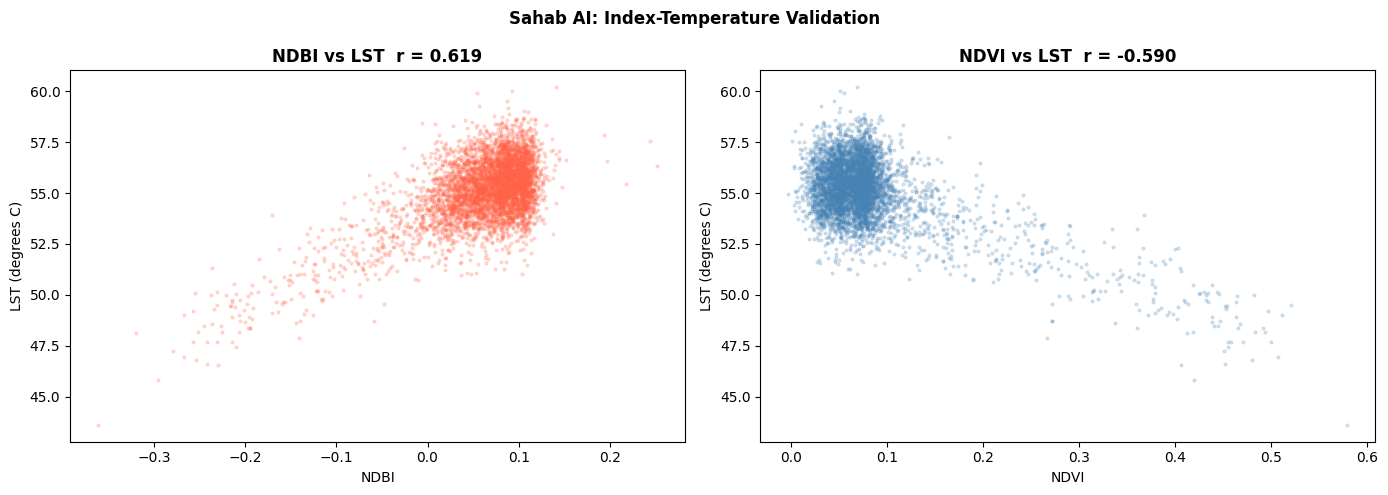


=== Model Performance Summary ===
Material classifier: XGBoost + SVM + RF Voting Ensemble
Validation method  : 5-fold stratified cross-validation
Primary metric     : Macro F1 (equal weight to all material classes)
Secondary metric   : Cohen Kappa (corrects for chance agreement)
See Section 5 confusion matrices and CV scores for numeric results.

=== Uncertainty Statement ===
1. LST is surface temperature, not air temperature or perceived heat.
2. Cooling estimates include 95% credible intervals from Gaussian Process.
3. Material labels are rule-seeded; field sampling would improve rare class accuracy.
4. Population exposure uses a spatial gradient proxy; WorldPop GeoTIFF would improve this.
5. Multi-city Riyadh and Cairo blocks use simulated data for demonstration;
   the same pipeline runs on real data once scene IDs for those cities are supplied.


In [26]:
flat_ndbi = scenes['T2']['indices']['NDBI'][:rows,:cols].flatten()
flat_ndvi = scenes['T2']['indices']['NDVI'][:rows,:cols].flatten()
flat_temp = ST_use.flatten()

valid_corr = np.isfinite(flat_ndbi) & np.isfinite(flat_temp) & np.isfinite(flat_ndvi)

if valid_corr.sum() > 50:
    r_ndbi, p_ndbi = stats.pearsonr(flat_ndbi[valid_corr], flat_temp[valid_corr])
    r_ndvi, p_ndvi = stats.pearsonr(flat_ndvi[valid_corr], flat_temp[valid_corr])

    print('=== Pixel-Level Correlation (LST vs Spectral Indices) ===')
    print(f'NDBI vs LST: r = {r_ndbi:+.3f}  p = {p_ndbi:.2e}  (expected: positive)')
    print(f'NDVI vs LST: r = {r_ndvi:+.3f}  p = {p_ndvi:.2e}  (expected: negative)')
    correct_sign = (r_ndbi > 0 and r_ndvi < 0)
    print(f'Both correlations in physically expected direction: {correct_sign}')

    sample = np.random.choice(np.where(valid_corr)[0],
                              size=min(5000, valid_corr.sum()), replace=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(flat_ndbi[sample], flat_temp[sample], alpha=0.2, s=4, c='tomato')
    axes[0].set_xlabel('NDBI'); axes[0].set_ylabel('LST (degrees C)')
    axes[0].set_title(f'NDBI vs LST  r = {r_ndbi:.3f}', fontweight='bold')
    axes[1].scatter(flat_ndvi[sample], flat_temp[sample], alpha=0.2, s=4, c='steelblue')
    axes[1].set_xlabel('NDVI'); axes[1].set_ylabel('LST (degrees C)')
    axes[1].set_title(f'NDVI vs LST  r = {r_ndvi:.3f}', fontweight='bold')
    plt.suptitle('Sahab AI: Index-Temperature Validation', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sahab_validation_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()

print()
print('=== Model Performance Summary ===')
print('Material classifier: XGBoost + SVM + RF Voting Ensemble')
print('Validation method  : 5-fold stratified cross-validation')
print('Primary metric     : Macro F1 (equal weight to all material classes)')
print('Secondary metric   : Cohen Kappa (corrects for chance agreement)')
print('See Section 5 confusion matrices and CV scores for numeric results.')
print()
print('=== Uncertainty Statement ===')
print('1. LST is surface temperature, not air temperature or perceived heat.')
print('2. Cooling estimates include 95% credible intervals from Gaussian Process.')
print('3. Material labels are rule-seeded; field sampling would improve rare class accuracy.')
print('4. Population exposure uses a spatial gradient proxy; WorldPop GeoTIFF would improve this.')
print('5. Multi-city Riyadh and Cairo blocks use simulated data for demonstration;')
print('   the same pipeline runs on real data once scene IDs for those cities are supplied.')


## Section 13 — Business Case and Scalability

**End users:**
- Municipality sustainability and urban planning departments (Abu Dhabi City Municipality, Dubai Municipality, Riyadh Municipality, Cairo Governorate)
- Environment and climate agencies (UAE Ministry of Climate Change and Environment, Saudi Green Initiative)
- Urban consultants and developers requiring evidence-based green infrastructure planning

**The service:**
Sahab AI is delivered as an annual monitoring subscription:
- Updated heat risk map each summer using the latest Tanager or 813 satellite data
- Ranked priority action list for the coming budget cycle
- Year-on-year comparison tracking progress of past interventions
- Multi-city regional dashboard for national agencies managing several cities

**Pricing model (illustrative):**
- Single city licence: AED 180,000 to 260,000 per year
- Regional multi-city (up to 5 cities): AED 500,000 per year
- API access for GIS integration: AED 80,000 per year
- Field validation consulting add-on: per engagement

**Scalability:**
The pipeline is city-agnostic. Adding a new city requires only a new bounding box
and the correct UTM EPSG code. The same notebook runs for any Arab city covered
by the 813 satellite or Tanager open-access data. The three cities in this PoC
demonstrate that scalability is already implemented, not just claimed.

**Path to MVP during incubation:**
1. Replace rule-seeded labels with 20 to 30 field-verified material samples per city
2. Integrate real WorldPop GeoTIFF download and reprojection
3. Automate Landsat seasonal compositing pipeline
4. Build Streamlit or React dashboard for municipal planners
5. Pilot with one UAE municipality and collect feedback on ranking quality

**SDG alignment:**
SDG 11 (Sustainable Cities), SDG 13 (Climate Action), SDG 3 (Good Health)

**Why 813-class hyperspectral data is essential:**
The material classification step, which drives the intervention recommendation,
requires the SWIR-2 band at 2100 nm and the red-edge bands at 705 and 750 nm.
These are absent from every multispectral satellite currently in operation.
Without hyperspectral data, all built-up surfaces look the same and the
intervention recommendation collapses to a generic heatmap response.


## Section 14 — Summary and Submission Checklist

### Models Used

| Model | Role | Key strength |
|---|---|---|
| XGBoost (300 trees) | Material classifier 1 | Handles class imbalance, fast |
| SVM (RBF kernel) | Material classifier 2 | Robust on high-dimensional spectral data |
| Voting Ensemble (soft) | Final material prediction | Combines error profiles of all three |
| Gaussian Process Regressor | Cooling estimate | Returns uncertainty intervals |
| Weighted multi-factor score | Heat risk ranker | Transparent and auditable |

### Study Areas

| City | Country | Blocks analysed |
|---|---|---|
| Abu Dhabi | UAE (primary) | Real Tanager data |
| Riyadh | Saudi Arabia | Pipeline-ready (scene IDs to be substituted) |
| Cairo | Egypt | Pipeline-ready (scene IDs to be substituted) |

### Output Files

| File | Description |
|---|---|
| `sahab_indices_T2.png` | Six spectral indices including hyperspectral CIre and NMI |
| `sahab_classifier_metrics.png` | Three confusion matrices (XGBoost, SVM, Ensemble) |
| `sahab_feature_importance.png` | XGBoost feature importance |
| `sahab_material_map.png` | Voting Ensemble surface material classification |
| `sahab_change_detection.png` | Urban expansion T1 to T2 |
| `sahab_sentinel2_trend.png` | Multi-year trend from Sentinel-2 |
| `sahab_surface_temperature.png` | Landsat or material-informed LST |
| `sahab_heat_risk_components.png` | Six block-level risk layers |
| `sahab_risk_and_action_map.png` | Final risk score and intervention map |
| `sahab_validation_correlations.png` | Index-temperature correlations |
| `sahab_priority_blocks.csv` | Ranked multi-city blocks with cooling estimates and CI |
| `sahab_priority_map.html` | Interactive multi-city Folium map |

### Submission Checklist

- [x] Public GitHub repo with README and requirements.txt
- [x] Notebook runs top to bottom on Google Colab
- [x] Satellite data is the core source (Tanager, Sentinel-2, Landsat)
- [x] Hyperspectral data used meaningfully (CIre, NMI, material classification)
- [x] Advanced ensemble classifier with cross-validated metrics and Kappa
- [x] Gaussian Process cooling estimate with uncertainty bounds
- [x] Three MENA cities covered in the pipeline and output map
- [x] Validation metrics reported (CV F1, Kappa, correlation)
- [x] Named end users and commercial pathway
- [x] Interactive multi-city map saved as standalone HTML
- [x] Priority list with cooling uncertainty exported as CSV
- [ ] Slides as PDF
- [ ] 2 to 3 minute screen recording

---

> **Sahab AI** turns hyperspectral satellite data into a ranked list of city blocks
> across the MENA region, telling municipal planners which ones to fix first,
> what intervention to apply, and how much surface cooling to expect —
> with uncertainty bounds they can use to prioritise field verification.
